# ***Introduction:***
Anomaly detection is the process of identifying unexpected items or events in data sets, which differ from the norm. Anomaly detection has two basic assumptions:

* Anomalies only occur very rarely in the data.

* Their features differ from the normal instances significantly.

This part is about the time series analysis.

# ***Import libraries:***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
register_matplotlib_converters()
from time import time

Dataset from: https://raw.githubusercontent.com/ritvikmath/Time-Series-Analysis/master/catfish.csv

In [ ]:
url = "https://raw.githubusercontent.com/ritvikmath/Time-Series-Analysis/master/catfish.csv"
DataSet = pd.read_csv(url)
DataSet

,Date,Total
0,1986-1-01,9034
1,1986-2-01,9596
2,1986-3-01,10558
3,1986-4-01,9002
4,1986-5-01,9239
...,...,...
319,2012-8-01,14442
320,2012-9-01,13422
321,2012-10-01,13795
322,2012-11-01,13352


In [ ]:
DataSet.describe()

,Total
count,324.000000
mean,19643.984568
std,5039.324331
min,8196.000000
25%,15764.000000
50%,19660.500000
75%,23604.500000
max,30485.000000


In [ ]:
#Preparing the data for process
def parser(s):
    return datetime.strptime(s, "%Y-%m-%d")

In [ ]:
df = pd.DataFrame(DataSet)
df.to_csv("CatFish.csv", index = False)

In [ ]:
#Read data
CatFishSales = pd.read_csv("CatFish.csv", parse_dates = [0], index_col = 0, squeeze = True, date_parser = parser)

In [ ]:
#Infer the frequency of the data
CatFishSales = CatFishSales.asfreq(pd.infer_freq(CatFishSales.index))

In [ ]:
StartDate = datetime(1996,1,1)
EndDate = datetime(2000,1,1)
Limit = CatFishSales[StartDate : EndDate]

In [ ]:
#At December 1 1998
#We add this one to make one really obvious anomaly!
Limit[datetime(1998,12,1)] = 10000

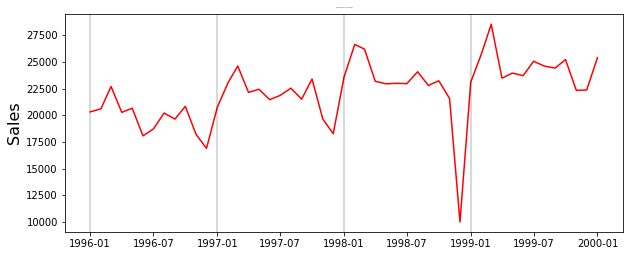

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Limit , color = "r")
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 0)
plt.ylabel("Sales", fontsize = 16)
#Separating the years to make them understang better
for year in range(StartDate.year,EndDate.year):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"), color = "k", linestyle = "-", alpha = 0.2)

So this is how our data look like!

**Note:** As we saw above we added one anomaly at 1st December 1998. Because based one the values of previous Decembers we expected the value to be in the same shape of before and maybe a bit higher in value because the plot is increasing after times passes. But by this assumption we make a really obvious anomaly! And the difference is really high! (It is not really impossible in normal life because in one season many things can happend that affected our data!)

We want to predicit the last 6 months of our 4 years data and use the 3,5 years first for training. In the following we start to make predictions based on detecting where anomaly is and handle it.

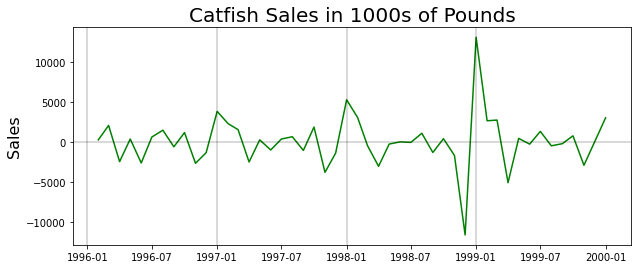

In [ ]:
#Without handling the anomaly
FirstDifferences = Limit.diff()[1:]
plt.figure(figsize = (10,4))
plt.plot(FirstDifferences , color = "g")
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 20)
plt.ylabel("Sales", fontsize = 16)
#Separating the years to make them understang better
for year in range(StartDate.year,EndDate.year):
    plt.axvline(pd.to_datetime(str(year) + "-01-01"), color = "k", linestyle = "-", alpha = 0.2)
plt.axhline(0, color = "k", linestyle = "-", alpha = 0.2)

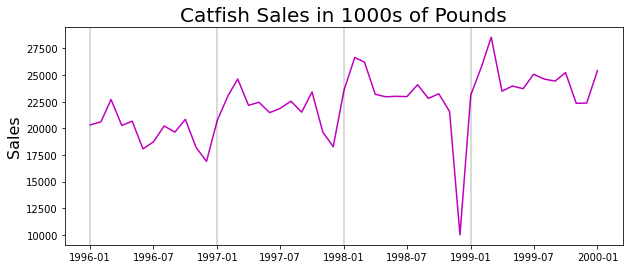

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Limit , color = "m")
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 20)
plt.ylabel("Sales", fontsize = 16)
for year in range(StartDate.year , EndDate.year):
    plt.axvline(pd.to_datetime(str(year) + "-01-01"), color = "k", linestyle = "-", alpha = 0.2)

In [ ]:
Deviations = pd.Series(dtype = float, index = Limit.index)

In [ ]:
for date in Deviations.index:
    #Window ending at this data point
    window = Limit.loc[:date]
    #Deviation within this window
    Deviations.loc[date] = window.std()

In [ ]:
#Difference in deviation between one time point and the next
DifferenceDeviations = Deviations.diff()
DifferenceDeviations = DifferenceDeviations.dropna()

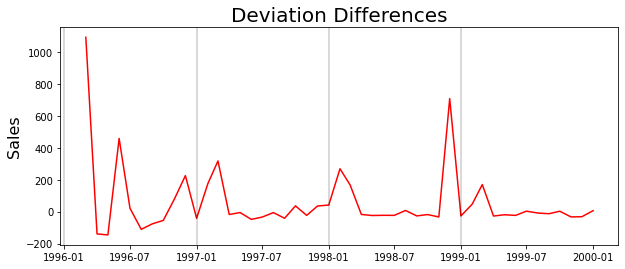

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(DifferenceDeviations , color = "r")
plt.title("Deviation Differences", fontsize=20)
plt.ylabel("Sales", fontsize=16)
for year in range(StartDate.year,EndDate.year):
    plt.axvline(pd.to_datetime(str(year)+"-01-01" ), color="k", linestyle="-", alpha = 0.2)

The Deviation in 1st of December 1998 is quite high...

In [ ]:
#Seasonal
MonthDeviations = Limit.groupby(lambda d: d.month).std()

Text(0, 0.5, 'Sales')

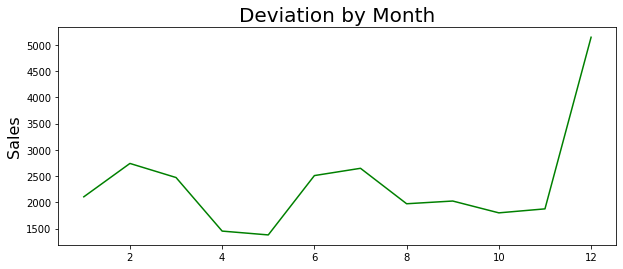

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(MonthDeviations , color = "g")
plt.title("Deviation by Month", fontsize = 20)
plt.ylabel("Sales", fontsize = 16)

So from this plot we can understand that the anomaly is in December.

In [ ]:
DecemberData = Limit[Limit.index.month == 12]
DecemberData

Date
1996-12-01    16898
1997-12-01    18278
1998-12-01    10000
1999-12-01    22372
Name: Total, dtype: int64

The smallest we choose!

In [ ]:
min_dev = 9999999
Anomaly = None
for date in DecemberData.index:
    other_data = DecemberData[DecemberData.index != date]
    curr_dev = other_data.std()
    if curr_dev < min_dev:
        min_dev = curr_dev
        Anomaly = date

In [ ]:
Anomaly

Timestamp('1998-12-01 00:00:00')

In [ ]:
TrainEndDate = datetime(1999,7,1)
TestEndDate = datetime(2000,1,1)
Test = Limit[TrainEndDate + timedelta(days=1):TestEndDate]

In [ ]:
Order = (0,1,0)
SeasonalOrder = (1, 0, 1, 12)

We use SARIMA model which is a seasonl auto reggressive integrated moving average in order to predict the last 6 months based on first 3.5 years.

In [ ]:
RollingPredictions = Test.copy()
for TrainEnd in Test.index:
    Train = Limit[:TrainEnd-timedelta(days=1)]
    Model = SARIMAX(Train, order=Order, seasonal_order=SeasonalOrder)
    ModelFit = Model.fit()
    Prediction = ModelFit.forecast()
    RollingPredictions[TrainEnd] = Prediction

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [ ]:
RollingResiduals = Test - RollingPredictions

Text(0, 0.5, 'Error')

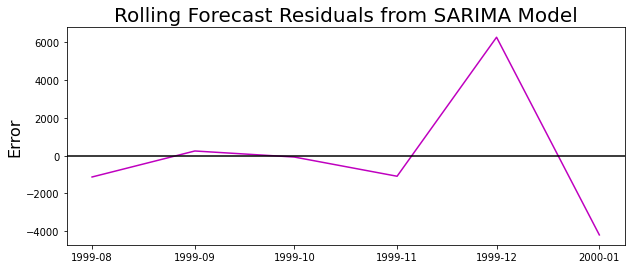

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(RollingResiduals , color = "m")
plt.axhline(0, linestyle = "-", color = "k")
plt.title("Rolling Forecast Residuals from SARIMA Model", fontsize = 20)
plt.ylabel("Error", fontsize = 16)

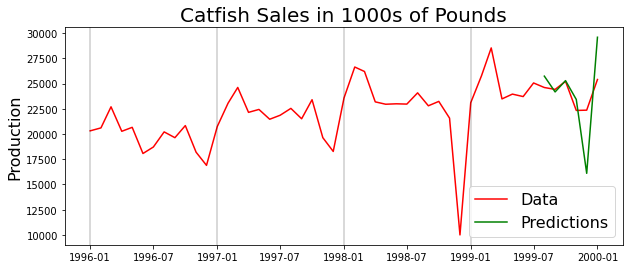

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Limit , color = "r")
plt.plot(RollingPredictions , color ="g")
plt.legend(("Data", "Predictions"), fontsize = 16)
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 20)
plt.ylabel("Production", fontsize = 16)
for year in range(StartDate.year , EndDate.year):
    plt.axvline(pd.to_datetime(str(year) + "-01-01"), color = "k", linestyle = "-", alpha = 0.2)

In [ ]:
print("Mean Absolute Percent Error:", round(np.mean(abs(RollingResiduals / Test)),4))

Mean Absolute Percent Error: 0.0921


In [ ]:
print("Root Mean Squared Error:", np.sqrt(np.mean(RollingResiduals ** 2)))

Root Mean Squared Error: 3144.3795890445545


We use to Predict without detecting the anomaly. Now it is time to predict with detecting the anomaly: One of the method is to use the mean of other months!

In [ ]:
#Use the mean of other months
Data = Limit.copy()
Data.loc[Anomaly] = DecemberData[(DecemberData.index != Anomaly) & (DecemberData.index < Test.index[0])].mean()

In [ ]:
Data = Limit.copy()
Data.loc[Anomaly] = DecemberData[(DecemberData.index != Anomaly) & (DecemberData.index < Test.index[0])].mean()

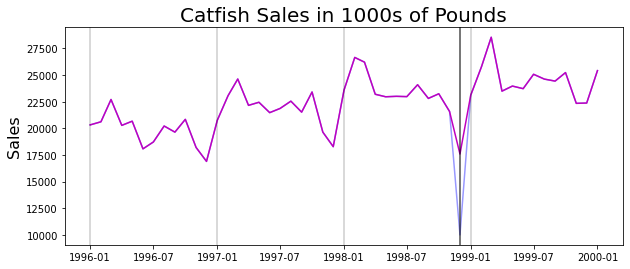

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Limit, color = "b" , alpha = 0.4)
plt.plot(Data , color = "m")
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 20)
plt.ylabel("Sales", fontsize = 16)
for year in range(StartDate.year,EndDate.year):
    plt.axvline(pd.to_datetime(str(year) + "-01-01"), color = "k", linestyle = "-", alpha = 0.2)
plt.axvline(Anomaly, color = "k", alpha = 0.7)

***Predict again:***

In [ ]:
TrainEndDate = datetime(1999,7,1)
TestEndDate = datetime(2000,1,1)
Test = Data[TrainEndDate + timedelta(days=1) : TestEndDate]

In [ ]:
Predictions = Test.copy()
for train_end in Test.index:
    Train = Data[:train_end-timedelta(days = 1)]
    Model = SARIMAX(Train, order=Order, seasonal_order = SeasonalOrder)
    ModelFit = Model.fit()
    Prediction = ModelFit.forecast()
    Predictions[train_end] = Prediction

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [ ]:
Residuals = Test - Predictions

Text(0, 0.5, 'Error')

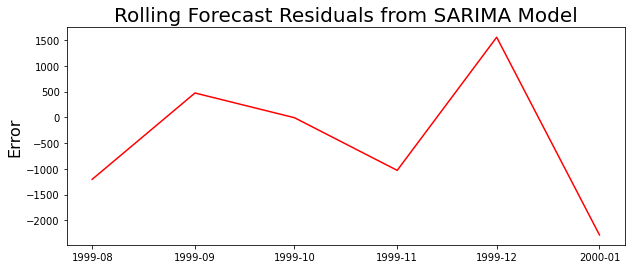

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Residuals , color = "r")
plt.title("Rolling Forecast Residuals from SARIMA Model", fontsize = 20)
plt.ylabel("Error", fontsize = 16)

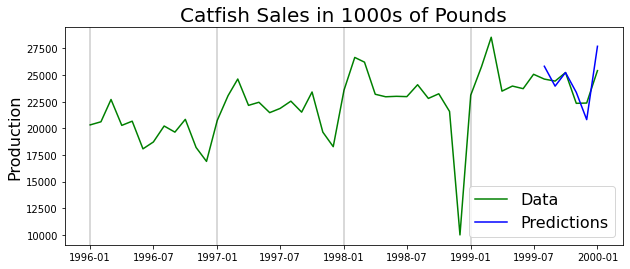

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(Limit , color = "g")
plt.plot(Predictions , "b")
plt.legend(("Data", "Predictions"), fontsize = 16)
plt.title("Catfish Sales in 1000s of Pounds", fontsize = 20)
plt.ylabel("Production" , fontsize = 16)
for year in range(StartDate.year,EndDate.year):
    plt.axvline(pd.to_datetime(str(year) + "-01-01"), color = "k", linestyle = "-", alpha = 0.2)

In [ ]:
print("Mean Absolute Percent Error:", round(np.mean(abs(Residuals / Test)),4))

Mean Absolute Percent Error: 0.0457


In [ ]:
print("Root Mean Squared Error:", np.sqrt(np.mean(Residuals ** 2)))

Root Mean Squared Error: 1314.793139623112


We can see the really obvious difference between the error after and before detecting the anomaly.

# ***Other Methods:***

We have different methods to detect the anomaly and here we saw one of them. Some of other methods:
* Isolation Forest Model : uses a tree-based approach to isolate anomalies
* DBSCAN : Density-based spatial clustering of applications with noise
* Support Vector Machine
* Local Outlier Factor (LOF) : found similar popularity and usage as DBSCAN
* Autoencoders


With this link you can see some examples. [Link](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html)